In [1]:
import scqubits
import numpy as np
from scipy.optimize import minimize

import sys
original_sys_path = sys.path.copy()
sys.path.append('../')
from utils import *
sys.path = original_sys_path

In [8]:
EJ = 2.75
EC = 0.6
EL = 0.13

qubit_level = 40

def get_shift_accurate(ele,omega_i, omega_j, omega_r):
    return abs(ele)**2 / (omega_j-omega_i-omega_r) - abs(ele)**2 / (omega_i-omega_j-omega_r)

qbt = scqubits.Fluxonium(EJ=EJ,EC=EC,EL=EL,flux=0,cutoff=110,truncated_dim=qubit_level)
evals = qbt.eigenvals(qubit_level)
elements = qbt.matrixelement_table('n_operator',evals_count = qubit_level)

def shift_diff(x):
    Er = x[0]
    shifts_from_zero = [get_shift_accurate(elements[0,ql2],evals[ql2],evals[0],Er) for ql2 in range(qubit_level)] 
    shift_from_zero = sum(shifts_from_zero)
    shifts_from_one = [get_shift_accurate(elements[1,ql2],evals[ql2],evals[1],Er) for ql2 in range(qubit_level)] 
    shift_from_one = sum(shifts_from_one)

    return abs(shift_from_one-shift_from_zero)

initial_guess = [6.88]

# Call the optimizer
result = minimize(shift_diff, initial_guess, bounds = [(6.8,6.9)],method='Nelder-Mead')

print("Result:", result)
print("Optimal solution:", result.x)
print("Objective value:", result.fun)


Result:        message: Optimization terminated successfully.
       success: True
        status: 0
           fun: 2.863805690714316e-07
             x: [ 6.844e+00]
           nit: 11
          nfev: 22
 final_simplex: (array([[ 6.844e+00],
                       [ 6.844e+00]]), array([ 2.864e-07,  8.346e-07]))
Optimal solution: [6.844375]
Objective value: 2.863805690714316e-07


qbt freq at osc 1:	2.36707, 	diff to at osc ground 0.00000, 0.0001% diff
qbt freq at osc 2:	2.36707, 	diff to at osc ground 0.00000, 0.0002% diff
qbt freq at osc 3:	2.36708, 	diff to at osc ground 0.00001, 0.0003% diff
qbt freq at osc 4:	2.36708, 	diff to at osc ground 0.00001, 0.0005% diff
qbt freq at osc 5:	2.36709, 	diff to at osc ground 0.00002, 0.0007% diff
qbt freq at osc 6:	2.36709, 	diff to at osc ground 0.00002, 0.0010% diff
qbt freq at osc 7:	2.36710, 	diff to at osc ground 0.00003, 0.0013% diff
qbt freq at osc 8:	2.36711, 	diff to at osc ground 0.00004, 0.0016% diff
qbt freq at osc 9:	2.36712, 	diff to at osc ground 0.00005, 0.0020% diff
qbt freq at osc 10:	2.36713, 	diff to at osc ground 0.00006, 0.0025% diff
qbt freq at osc 11:	2.36714, 	diff to at osc ground 0.00007, 0.0030% diff
qbt freq at osc 12:	2.36715, 	diff to at osc ground 0.00008, 0.0036% diff
qbt freq at osc 13:	2.36717, 	diff to at osc ground 0.00010, 0.0042% diff
qbt freq at osc 14:	2.36718, 	diff to at osc gr

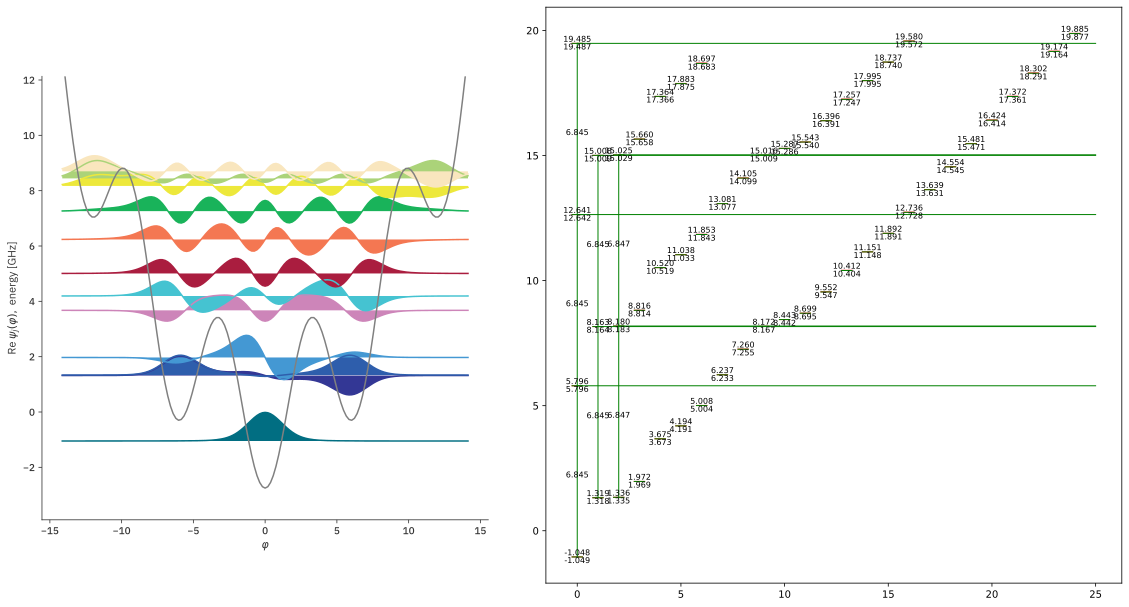

In [10]:

g = 0.13


max_ol = 40
max_ql = 30
system = fluxonium_oscillator_system(
    EJ = EJ,
    EC = EC,
    EL = EL,
    Er = result.x[0],
    g_strength = g,
    qubit_level = max_ql,
    osc_level = max_ol,
    kappa = 0.004,
    products_to_keep=[[ql, ol] for ql in range(max_ql) for ol in range(max_ol) ],
    computaional_states = '0,1'
    )


energies=  system.hilbertspace.eigenvals(max_ql * max_ol)
def dressed_ener(ql,ol):
    return energies[system.product_to_dressed[(ql,ol)]]
def print_stats():
    ground_freq = dressed_ener(1,0)-dressed_ener(0,0)
    for i in range(1,max_ol-1):
        freq = dressed_ener(1,i)-dressed_ener(0,i)
        print(f"qbt freq at osc {i}:\t{freq:.5f}, \tdiff to at osc ground {freq - ground_freq:.5f}, {abs(freq - ground_freq)/ground_freq*100:.4f}% diff")

    print(f"\noscillator freq at qubit level:\t0 \t 1 \t 2 \t 3:")
    print(f"oscillator transition 0-1: \t{dressed_ener(0,1)-dressed_ener(0,0):.5f}\t{dressed_ener(1,1)-dressed_ener(1,0):.5f}\t{dressed_ener(2,1)-dressed_ener(2,0):.5f}\t{dressed_ener(3,1)-dressed_ener(3,0):.5f}")
    for i in range(1,max_ol-1):
        print(f"oscillator transition {i}-{i+1}: \t{dressed_ener(0,i+1)-dressed_ener(0,i):.5f}\t{dressed_ener(1,i+1)-dressed_ener(1,i):.5f}\t{dressed_ener(2,i+1)-dressed_ener(2,i):.5f}\t{dressed_ener(3,i+1)-dressed_ener(3,i):.5f}  oscillator frequency coupled to qubit 2nd state compared to 20-21 (non-linearity): {(dressed_ener(2,i+1)-dressed_ener(2,i))  -(dressed_ener(2,1)-dressed_ener(2,0))}")

    print(f"")
    print(f"00-01: {(dressed_ener(0,1)-dressed_ener(0,0)):.4f}, diff to 20-01: {abs((dressed_ener(0,1)-dressed_ener(0,0))    -(dressed_ener(2,1)-dressed_ener(2,0)))}")
    print(f"10-11: {(dressed_ener(1,1)-dressed_ener(1,0)):.4f}, diff to 20-01: {abs((dressed_ener(1,1)-dressed_ener(1,0))    -(dressed_ener(2,1)-dressed_ener(2,0)))}")
print_stats()
plot_specturum(system.qbt, system.osc, system.hilbertspace,num_levels = 50)